In [10]:
import os
import sys
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

SCRIPT_DIR = os.path.dirname(os.path.realpath(os.path.join(os.path.dirname(os.getcwd()))))
sys.path.append(SCRIPT_DIR)

import gwfast.gwfastGlobals as glob
import gwfast.waveforms as waveforms
import gwfast.signal as signal
import gwfast.network as network

In [11]:
# Set up detectors
mywf = waveforms.IMRPhenomD()

L1_conf = copy.deepcopy(glob.detectors).pop('L1')
L1_conf['psd_path'] = os.path.join(glob.detPath, 'observing_scenarios_paper', 'AplusDesign.txt')

H1_conf = copy.deepcopy(glob.detectors).pop('H1')
H1_conf['psd_path'] = os.path.join(glob.detPath, 'observing_scenarios_paper', 'AplusDesign.txt')

Virgo_conf = copy.deepcopy(glob.detectors).pop('Virgo')
Virgo_conf['psd_path'] =  os.path.join(glob.detPath, 'observing_scenarios_paper', 'avirgo_O5low_NEW.txt')

# Initialise GWSignal objects
L1 = signal.GWSignal(mywf, psd_path=L1_conf['psd_path'], 
                        detector_shape=L1_conf['shape'], det_lat=L1_conf['lat'], 
                        det_long=L1_conf['long'], det_xax=L1_conf['xax'],
                        fmin=10
                        )
H1 = signal.GWSignal(mywf, psd_path=H1_conf['psd_path'], 
                        detector_shape=H1_conf['shape'], det_lat=H1_conf['lat'], 
                        det_long=H1_conf['long'], det_xax=H1_conf['xax'],
                        fmin=10
                        )
Virgo = signal.GWSignal(mywf, psd_path=Virgo_conf['psd_path'], 
                        detector_shape=Virgo_conf['shape'], det_lat=Virgo_conf['lat'], 
                        det_long=Virgo_conf['long'], det_xax=Virgo_conf['xax'],
                        fmin=10
                        )

mySignals = {'L1':L1, 'H1':H1, 'Virgo':Virgo}
myNet = network.DetNet(mySignals)

Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/AplusDesign.txt 
Initializing jax...
Jax local device count: 1
Jax device count: 1
Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/AplusDesign.txt 
Initializing jax...
Jax local device count: 1
Jax device count: 1
Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/avirgo_O5low_NEW.txt 
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [12]:
# Define a benchmark event
n = 20
shape = (n, n)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'chiS':np.full(shape, 0.3), 'chiA':np.full(shape, 0.5), 'chi1x':np.full(shape, 0), 'chi2x':np.full(shape, 0), 'chi1y':np.full(shape, 0), 'chi2y':np.full(shape, 0), 
    'LambdaTilde':np.full(shape, 0), 'deltaLambda':np.full(shape, 0), 'ecc':np.full(shape, 0), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5)
}

# Compute benchmark SNR
event = {key: values[0, 0] for key, values in events.items()}
mySNR = myNet.SNR(event, use_lensing=True, return_all=True)
print("SNR with lensing:", mySNR)

Adding chi1z, chi2z from chiS, chiA
SNR with lensing: {'L1': Array(13.19938096, dtype=float64), 'H1': Array(27.44081629, dtype=float64), 'Virgo': Array(5.86537915, dtype=float64), 'net': 31.010074637246582}


In [13]:
# This is the order of parameters in GWStrain
strain_parameters = ['Mc', 'eta', 'dL', 'theta', 'phi', 'iota', 'psi', 
                     'tcoal', 'phase', 'chiS', 'chiA', 'chi1x', 'chi2x', 'chi1y', 'chi2y', 
                     'LambdaTilde', 'deltaLambda', 'ecc']
# Add the lensed parameters as well
strain_parameters += ['R_orbit', 'M_lz', 'src_pos']

# Waveform metadata
sampling_frequency = 1024.  # Hz
minimum_frequency = 10.  # Hz
maximum_frequency = sampling_frequency / 2
N_freq_bins = 1000

# Make frequency grid
minimum_frequency_array = np.full(shape, minimum_frequency)
maximum_frequency_array = np.full(shape, maximum_frequency)
freq_grid = np.geomspace(minimum_frequency_array, maximum_frequency_array, N_freq_bins)

# Interpolate PSD
freq_array = np.geomspace(minimum_frequency, maximum_frequency, N_freq_bins)
psd_interp = np.interp(freq_array, L1.strainFreq, L1.noiseCurve)
psd_interp_grid = np.reshape(np.repeat(psd_interp, n**2), (-1, n, n))

# Coupled time and freq array method temporarily set aside bc I keep messing it up with the freq grid
# # Waveform metadata
# sampling_frequency = 1024.  # Hz
# duration = 8.  # s

# minimum_frequency = 10.  # Hz
# # This maximum frequency need not equal to fs/2
# maximum_frequency = sampling_frequency / 2

# # This procedure to create coupled time and freq arrays is borrowed from Bilby
# N_samples = int(np.round(duration * sampling_frequency))
# N_freq_bins = int(np.round(N_samples / 2) + 1)
# freq_array = np.linspace(0, maximum_frequency, N_freq_bins)
# # time_array = np.linspace(0, duration - 1 / sampling_frequency, N_samples
# freq_grid = np.reshape(np.repeat(freq_array, n**2), (-1, n, n))

# freq_mask = (freq_array > minimum_frequency) & (freq_array < maximum_frequency)
# masked_freq_array = freq_array[np.where(freq_mask)]
# masked_freq_grid = np.reshape(np.repeat(masked_freq_array, n**2), (-1, n, n))

# # Generate strains
# FD_strain_lensed = np.zeros_like(freq_grid, dtype='complex128')
# FD_strain_unlensed = np.zeros_like(freq_grid, dtype='complex128')


In [14]:
# Mismatch definition
def inner_product(frequencies, h1, h2, psd):
    integrand = np.conj(h1) * h2 / psd
    return 4 * np.real(np.trapz(integrand, frequencies, axis=0))

def mismatch(frequencies, h1, h2, psd):
    return inner_product(frequencies, h1-h2, h1-h2, psd) / (2 * (inner_product(frequencies, h1, h1, psd) + inner_product(frequencies, h2, h2, psd)))

In [15]:
# Sample parameter space
R_orbit_array = np.geomspace(20, 1000, n)
Mc_array = np.linspace(10, 100, n)
M_lz_array = np.geomspace(5e3, 5e6, n)
src_pos_array = np.linspace(0.05, 0.5, n)

In [16]:
# Prepare injections
R_orbit_mesh, Mc_mesh = np.meshgrid(R_orbit_array, Mc_array, indexing='xy')
events_copy_1 = events.copy()
events_copy_1['R_orbit'] = R_orbit_mesh
events_copy_1['Mc'] = Mc_mesh

R_orbit_mesh, M_lz_mesh = np.meshgrid(R_orbit_array, M_lz_array, indexing='xy')
events_copy_2 = events.copy()
events_copy_2['R_orbit'] = R_orbit_mesh
events_copy_2['M_lz'] = M_lz_mesh

R_orbit_mesh, src_pos_mesh = np.meshgrid(R_orbit_array, src_pos_array, indexing='xy')
events_copy_3 = events.copy()
events_copy_3['R_orbit'] = R_orbit_mesh
events_copy_3['src_pos'] = src_pos_mesh

# Generate strains
FD_strain_lensed_1 = L1.GWstrain(freq_grid, *[events_copy_1[key] for key in strain_parameters], use_lensing=True)
FD_strain_unlensed_1 = L1.GWstrain(freq_grid, *[events_copy_1[key] for key in strain_parameters], use_lensing=False)

FD_strain_lensed_2 = L1.GWstrain(freq_grid, *[events_copy_2[key] for key in strain_parameters], use_lensing=True)
FD_strain_unlensed_2 = L1.GWstrain(freq_grid, *[events_copy_2[key] for key in strain_parameters], use_lensing=False)

FD_strain_lensed_3 = L1.GWstrain(freq_grid, *[events_copy_3[key] for key in strain_parameters], use_lensing=True)
FD_strain_unlensed_3 = L1.GWstrain(freq_grid, *[events_copy_3[key] for key in strain_parameters], use_lensing=False)

# Compute mismatch
mismatch_1 = mismatch(freq_grid, FD_strain_lensed_1, FD_strain_unlensed_1, psd_interp_grid)
mismatch_2 = mismatch(freq_grid, FD_strain_lensed_2, FD_strain_unlensed_2, psd_interp_grid)
mismatch_3 = mismatch(freq_grid, FD_strain_lensed_3, FD_strain_unlensed_3, psd_interp_grid)

Text(0, 0.5, '$y$')

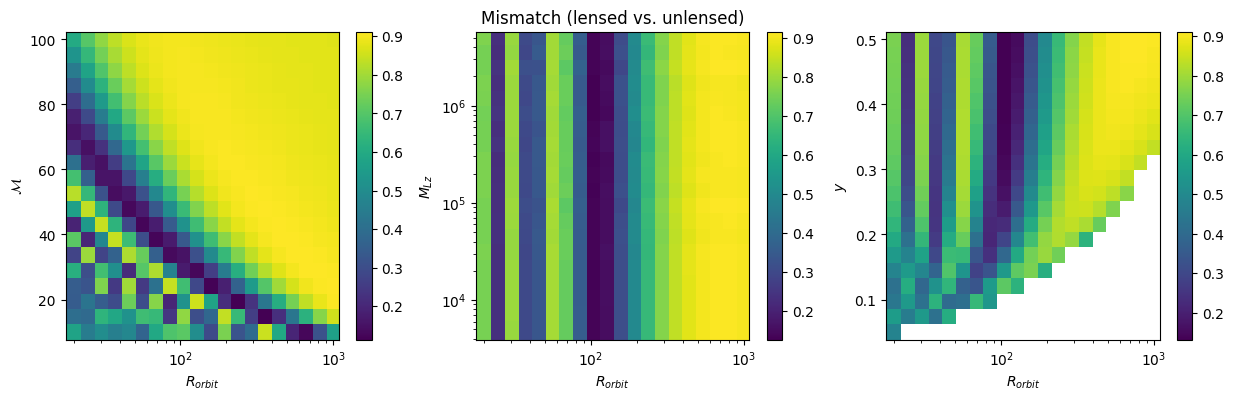

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

ax = axs[0]
im = ax.pcolormesh(R_orbit_array, Mc_array, mismatch_1)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$\cal M$')

ax = axs[1]
im = ax.pcolormesh(R_orbit_array, M_lz_array, mismatch_2)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Mismatch (lensed vs. unlensed)')
ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$M_{Lz}$')

ax = axs[2]
im = ax.pcolormesh(R_orbit_array, src_pos_array, mismatch_3)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$y$')